# TikTok EMA Project — Ridge Regression Pipeline

## Goal
Test whether session-level behavioral and audio/content features predict EMA outcomes using Ridge regression.

We compare three models of increasing complexity:
- **Model A**: behavioral features only (from DDP logs)
- **Model B**: behavioral + handcrafted audio features (from Librosa)
- **Model C**: behavioral + handcrafted audio + AST deep embeddings (768-dim, PCA-reduced)

The unit of analysis is one **EMA burst** (2-hour pre-survey window) per participant.

Ridge regression is appropriate here because:
- We have many features relative to observations (pilot: N=20)
- L2 regularization handles multicollinearity
- Coefficients remain interpretable


## 1. Imports and Data Loading

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

df = pd.read_csv("final_model_df.csv")

# Some ddp_matchtime_* columns store empty bursts as '[]' strings — convert to NaN
df = df.replace('[]', np.nan)

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 150 rows × 2055 columns


## 2. Initial Inspection

Check shape, missing values, and outcome distributions before doing anything else.

In [2]:
print("Shape:", df.shape)
print("\nFirst 3 rows (non-feature columns only):")
meta_cols = [c for c in df.columns if c in ["PID", "Start Date", "happy", "life_satisfied",
                                              "smu_intention_pc", "smu_experience_happy",
                                              "pilot_n_videos_sampled", "pilot_n_videos_with_features",
                                              "ddp_num_view_burst", "ddp_num_like_burst"]]
display(df[meta_cols].head(3))

print("\nMissing values (top 20 columns with most NaNs):")
missing = df.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False).head(20))

Shape: (150, 2055)

First 3 rows (non-feature columns only):


,PID,Start Date,pilot_n_videos_with_features,pilot_n_videos_sampled,happy,life_satisfied,smu_experience_happy,smu_intention_pc,ddp_num_like_burst,ddp_num_view_burst
0,55ec49b67480920010aaa4e8,07/16/2025 02:19PM,5,5,38.0,41.0,3.0,0.111111,0.0,88.0
1,55ec49b67480920010aaa4e8,07/21/2025 02:07PM,3,5,49.0,47.0,3.0,0.111111,0.0,27.0
2,57886b106cc44500010441f5,07/21/2025 06:37PM,4,5,86.0,87.0,4.0,0.285714,NaN,83.0



Missing values (top 20 columns with most NaNs):


life_activity                  150
act_intention_text             150
instruction                    150
act_motivation                 150
life_activity_2                150
act_intention                  150
platform_text                  150
ddp_matchtime_post_burst       147
ddp_matchtime_comment_burst    135
label_manual                   131
ddp_matchtime_fol_burst        127
ddp_matchtime_share_burst      126
app_Photo_burst                123
app_Facebook_burst             123
app_Reddit_burst               123
app_TikTok_burst               123
app_Game_burst                 123
app_Message_burst              123
app_YouTube_burst              123
app_Shop_burst                 123
dtype: int64

In [3]:
# Outcome variable distributions
outcomes_to_check = ["happy", "smu_intention_pc", "smu_experience_happy", "life_satisfied"]
print("Outcome variable summaries:")
for col in outcomes_to_check:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].describe().round(2))
    else:
        print(f"  WARNING: '{col}' not found in dataframe")

Outcome variable summaries:

happy:
count    150.00
mean      60.19
std       28.10
min        0.00
25%       44.00
50%       61.00
75%       81.00
max      100.00
Name: happy, dtype: float64

smu_intention_pc:
count    150.00
mean      -0.07
std        0.80
min       -2.93
25%       -0.41
50%        0.00
75%        0.34
max        2.86
Name: smu_intention_pc, dtype: float64

smu_experience_happy:
count    150.00
mean       3.79
std        0.99
min        1.00
25%        3.00
50%        4.00
75%        4.00
max        5.00
Name: smu_experience_happy, dtype: float64

life_satisfied:
count    150.00
mean      60.59
std       27.73
min        0.00
25%       46.25
50%       62.00
75%       82.75
max      100.00
Name: life_satisfied, dtype: float64


## 3. Outcome Selection

Change `target` here to switch between outcome variables.

Available outcomes:
- `"happy"` — momentary happiness (0–100)
- `"smu_intention_pc"` — social media use intention (person-centered)
- `"smu_experience_happy"` — happiness during SMU
- `"life_satisfied"` — life satisfaction

In [4]:
target = "happy"  # ← change this to switch outcome variable

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in dataframe. "
                     f"Available outcomes: {outcomes_to_check}")

y = df[target].values
print(f"Target: {target}")
print(f"  N={len(y)}, mean={y.mean():.2f}, std={y.std():.2f}, "
      f"min={y.min():.2f}, max={y.max():.2f}")
print(f"  Missing: {np.isnan(y).sum()}")

Target: happy
  N=150, mean=60.19, std=28.00, min=0.00, max=100.00
  Missing: 0


## 4. Feature Grouping

Features are split into three groups based on column name patterns:
- **Behavioral**: DDP-derived event counts and durations
- **Handcrafted audio**: Librosa features aggregated per burst (mean + std)
- **AST embeddings**: 768-dim deep audio representation (mean per burst, PCA-reduced before modeling)

In [5]:
# Columns to always exclude
exclude = {"PID", "Start Date", target, "pilot_n_videos_sampled",
           "pilot_n_videos_with_features"}

all_cols = set(df.columns) - exclude

# Behavioral: DDP-computed burst/person summaries
behav_patterns = ["ddp_", "app_Browser"]
behav_cols = sorted([
    c for c in all_cols
    if any(c.startswith(p) or p in c for p in behav_patterns)
])

# AST: deep embedding dimensions (use only _mean, not _std, for the PCA block)
ast_mean_cols = sorted([c for c in all_cols if c.startswith("ast_") and c.endswith("_mean")])
ast_std_cols  = sorted([c for c in all_cols if c.startswith("ast_") and c.endswith("_std")])
# Use only means for PCA (std adds noise at N=150)
ast_cols = ast_mean_cols

# Handcrafted audio: everything else that looks like an audio feature
audio_patterns = ["mfcc", "chroma", "tempo", "rms_", "zcr_", "tonnetz",
                  "centroid", "rolloff", "bandwidth", "contrast",
                  "beat_count", "non_silence"]
audio_cols = sorted([
    c for c in all_cols
    if any(p in c for p in audio_patterns)
    and not c.startswith("ast_")
])

# Drop any columns that aren't numeric (e.g. ddp_matchtime_* contain timestamp lists)
def keep_numeric(cols, df):
    return [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

behav_cols = keep_numeric(behav_cols, df)
audio_cols  = keep_numeric(audio_cols, df)
ast_cols    = keep_numeric(ast_cols, df)

print(f"Behavioral features    : {len(behav_cols)}")
print(f"Handcrafted audio      : {len(audio_cols)}")
print(f"AST mean dims (PCA in) : {len(ast_cols)}")
print(f"\nSample behavioral : {behav_cols[:4]}")
print(f"Sample audio      : {audio_cols[:4]}")
print(f"Sample AST        : {ast_cols[:4]}")

Behavioral features    : 42
Handcrafted audio      : 264
AST mean dims (PCA in) : 768

Sample behavioral : ['app_Browser_burst', 'app_Browser_person', 'app_Browser_personday', 'ddp_active_days']
Sample audio      : ['bandwidth_1_mean_sess_mean', 'bandwidth_1_mean_sess_std', 'bandwidth_1_std_sess_mean', 'bandwidth_1_std_sess_std']
Sample AST        : ['ast_100_mean', 'ast_101_mean', 'ast_102_mean', 'ast_103_mean']


## 5. Build Three Feature Matrices

- **Model A**: behavior only — establishes a baseline
- **Model B**: behavior + handcrafted audio — tests whether Librosa features add signal
- **Model C**: behavior + handcrafted audio + AST embeddings — tests whether deep representations add signal beyond engineered features

Note: at pilot scale (N=20), improvements in R² may be small or noisy. The goal is to establish whether the pipeline works and whether content features are worth pursuing at scale.

In [6]:
# Filter to columns that actually exist in df
def filter_cols(cols, df):
    present = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        warnings.warn(f"{len(missing)} columns not found and skipped: {missing[:5]}")
    return present

behav_cols = filter_cols(behav_cols, df)
audio_cols  = filter_cols(audio_cols, df)
ast_cols    = filter_cols(ast_cols, df)

feat_A = behav_cols
feat_B = behav_cols + audio_cols
feat_C = behav_cols + audio_cols  # AST handled separately via ColumnTransformer

print(f"Model A features: {len(feat_A)}")
print(f"Model B features: {len(feat_B)}")
print(f"Model C features: {len(feat_C)} + {len(ast_cols)} AST dims (→ PCA)")

Model A features: 42
Model B features: 306
Model C features: 306 + 768 AST dims (→ PCA)


## 6. Preprocessing

- Missing values → mean imputation
- All features → StandardScaler
- AST block → PCA (n_components=20) applied after scaling

`n_pca = 20` is conservative for N=20. At scale, increase this.

In [7]:
N_PCA = 30   # With N=150, LOO train size = 149 — 30 components is safe and captures more AST signal
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

def make_pipeline_AB(feature_cols):
    """impute → scale → RidgeCV"""
    return Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale",  StandardScaler()),
        ("ridge",  RidgeCV(alphas=ALPHAS, scoring="r2")),
    ])

def make_pipeline_C(non_ast_cols, ast_cols, n_pca, n_samples):
    """impute+scale non-AST; impute+scale+PCA for AST; RidgeCV.
    PCA n_components is capped at min(n_pca, n_ast_cols, n_samples-1).
    """
    safe_n = min(n_pca, len(ast_cols), n_samples - 1)
    non_ast_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale",  StandardScaler()),
    ])
    ast_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale",  StandardScaler()),
        ("pca",    PCA(n_components=safe_n)),
    ])
    ct = ColumnTransformer([
        ("non_ast", non_ast_pipe, non_ast_cols),
        ("ast",     ast_pipe,     ast_cols),
    ])
    return Pipeline([
        ("preprocess", ct),
        ("ridge",      RidgeCV(alphas=ALPHAS, scoring="r2")),
    ])

print(f"N_PCA: {N_PCA}")
print(f"Ridge alpha grid: {ALPHAS}")

N_PCA: 30
Ridge alpha grid: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]


## 7. Cross-Validation

We use **Leave-One-Group-Out (LOGO) CV** grouped by participant ID (`PID`).

- Some participants contribute multiple bursts (up to 3). LOO by row would let a participant's other bursts into the training fold when one of their bursts is held out — inflating generalization estimates.
- LOGO holds out **all bursts from one participant at a time**, so the model is always evaluated on a person it has never seen during training.
- This gives 120 folds (one per unique PID) and is the correct choice if the goal is to generalize to new participants.

In [8]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import r2_score, root_mean_squared_error

logo = LeaveOneGroupOut()

# Drop rows where target is missing
df_model = df.dropna(subset=[target]).copy()
y = df_model[target].values
groups = df_model["PID"].values
n = len(df_model)
n_groups = len(np.unique(groups))
print(f"Rows used for modeling : {n}  (dropped {len(df) - n} with missing target)")
print(f"CV strategy            : Leave-One-Group-Out by PID ({n_groups} folds)")

def evaluate_model(pipe, X, y, cv, groups):
    """
    Get out-of-fold predictions via LOGO CV, then compute R² and RMSE
    on the full pooled predictions. This avoids undefined per-fold R²
    (which occurs when a participant contributes only 1 burst to their test fold).
    """
    y_pred = cross_val_predict(pipe, X, y, cv=cv, groups=groups)
    r2   = r2_score(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    residuals = y - y_pred
    return {
        "r2":        r2,
        "rmse":      rmse,
        "y_pred":    y_pred,
        "residuals": residuals,
    }

# Model A
pipe_A = make_pipeline_AB(feat_A)
X_A = df_model[feat_A]
res_A = evaluate_model(pipe_A, X_A, y, logo, groups)
print(f"\nModel A — R²: {res_A['r2']:.3f}   RMSE: {res_A['rmse']:.3f}")

# Model B
pipe_B = make_pipeline_AB(feat_B)
X_B = df_model[feat_B]
res_B = evaluate_model(pipe_B, X_B, y, logo, groups)
print(f"Model B — R²: {res_B['r2']:.3f}   RMSE: {res_B['rmse']:.3f}")

# Model C
pipe_C = make_pipeline_C(feat_C, ast_cols, N_PCA, n)
X_C = df_model[feat_C + ast_cols]
res_C = evaluate_model(pipe_C, X_C, y, logo, groups)
print(f"Model C — R²: {res_C['r2']:.3f}   RMSE: {res_C['rmse']:.3f}")

Rows used for modeling : 150  (dropped 0 with missing target)
CV strategy            : Leave-One-Group-Out by PID (120 folds)

Model A — R²: -0.133   RMSE: 29.809
Model B — R²: -0.077   RMSE: 29.060
Model C — R²: -0.079   RMSE: 29.085


## 8. Summary Table

In [9]:
summary = pd.DataFrame({
    "Model": ["A: Behavior", "B: Behavior + Audio", "C: Behavior + Audio + AST"],
    "N features": [len(feat_A), len(feat_B), len(feat_C) + min(N_PCA, len(ast_cols))],
    "R² (OOF)":  [res_A['r2'],   res_B['r2'],   res_C['r2']],
    "RMSE (OOF)":[res_A['rmse'], res_B['rmse'], res_C['rmse']],
})
summary = summary.round(4)
display(summary)

,Model,N features,R² (OOF),RMSE (OOF)
0,A: Behavior,42,-0.1332,29.8094
1,B: Behavior + Audio,306,-0.0769,29.0596
2,C: Behavior + Audio + AST,336,-0.0788,29.0848


## 9. Visualizations

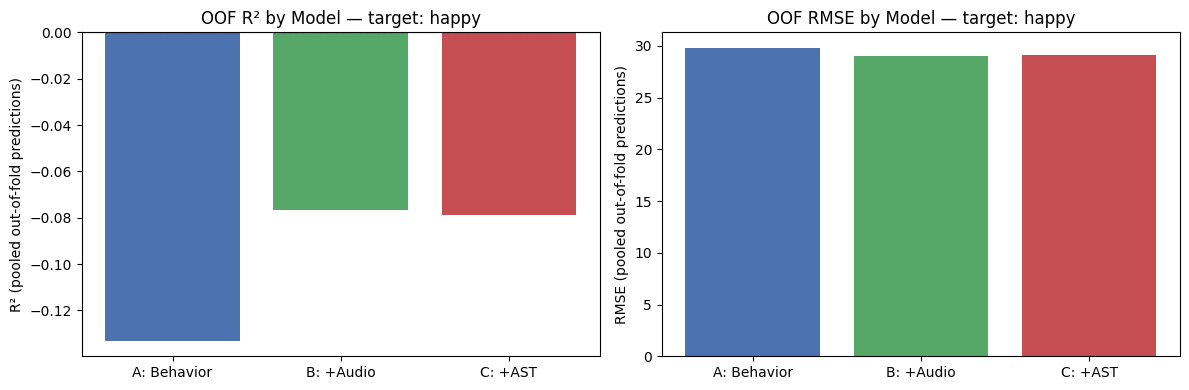

In [10]:
model_names = ["A: Behavior", "B: +Audio", "C: +AST"]
r2_vals   = [res_A['r2'],   res_B['r2'],   res_C['r2']]
rmse_vals = [res_A['rmse'], res_B['rmse'], res_C['rmse']]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(model_names, r2_vals, color=colors)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title(f"OOF R² by Model — target: {target}")
axes[0].set_ylabel("R² (pooled out-of-fold predictions)")

axes[1].bar(model_names, rmse_vals, color=colors)
axes[1].set_title(f"OOF RMSE by Model — target: {target}")
axes[1].set_ylabel("RMSE (pooled out-of-fold predictions)")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

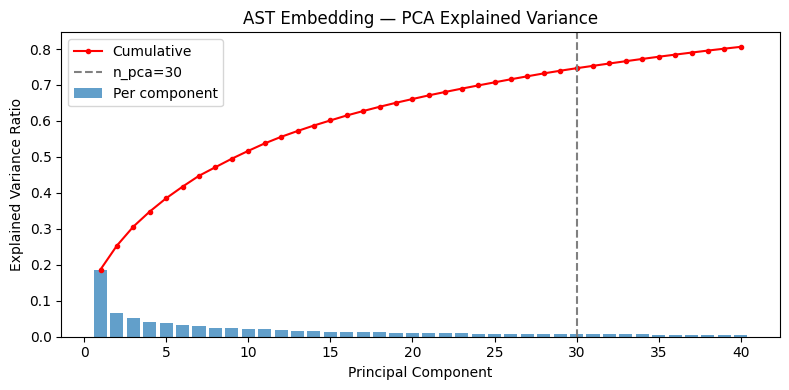

Variance explained by first 30 components: 0.747


In [11]:
# PCA explained variance for AST features
X_ast = df_model[ast_cols].copy()
imp = SimpleImputer(strategy="mean")
scl = StandardScaler()
X_ast_imputed = scl.fit_transform(imp.fit_transform(X_ast))

pca_full = PCA(n_components=min(40, len(ast_cols))).fit(X_ast_imputed)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_, alpha=0.7, label="Per component")
ax.plot(range(1, len(cumvar) + 1), cumvar, color="red", marker="o", markersize=3, label="Cumulative")
ax.axvline(N_PCA, color="gray", linestyle="--", label=f"n_pca={N_PCA}")
ax.set_title("AST Embedding — PCA Explained Variance")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.legend()
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150)
plt.show()

print(f"Variance explained by first {N_PCA} components: {cumvar[N_PCA-1]:.3f}")

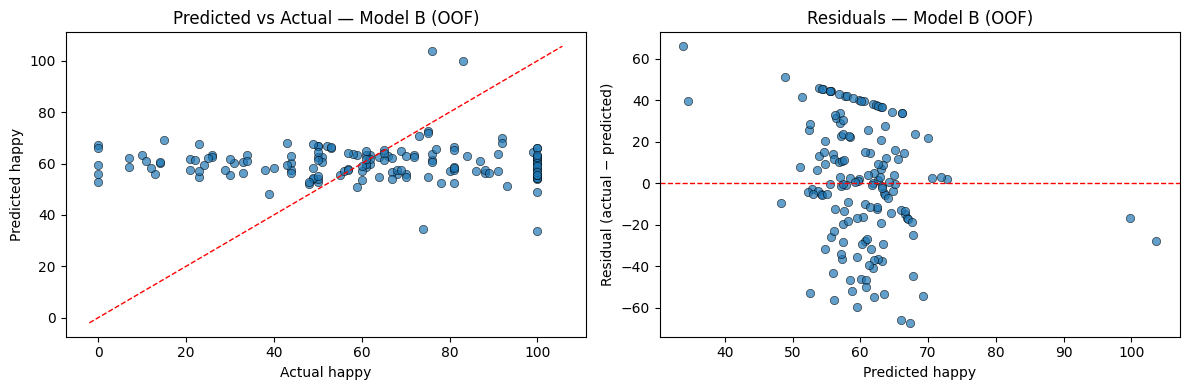

In [12]:
# Predicted vs actual + residuals — using OOF predictions (not training fit)
best_name, best_res = max(
    [("A", res_A), ("B", res_B), ("C", res_C)],
    key=lambda t: t[1]["r2"]
)
y_pred    = best_res["y_pred"]
residuals = best_res["residuals"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y, y_pred, alpha=0.7, edgecolors="k", linewidths=0.5)
lims = [min(y.min(), y_pred.min()) - 2, max(y.max(), y_pred.max()) + 2]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel(f"Actual {target}")
axes[0].set_ylabel(f"Predicted {target}")
axes[0].set_title(f"Predicted vs Actual — Model {best_name} (OOF)")

axes[1].scatter(y_pred, residuals, alpha=0.7, edgecolors="k", linewidths=0.5)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel(f"Predicted {target}")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title(f"Residuals — Model {best_name} (OOF)")

plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
plt.show()

## 10. Interpretation

Use this section to reason about what the numbers mean.

### If Model C improves over A and B:
→ Deep audio representations (AST embeddings) carry signal about emotional experience beyond behavioral counts and engineered features. This supports the value of content-level features for EMA prediction.

### If improvements are small or unstable:
→ At N=20, this is expected. Ridge CV R² estimates at this sample size have high variance (std across folds may exceed the mean). Do not over-interpret.

### If Model A already fits well:
→ Behavioral counts (views, likes, duration) may be sufficient proxies at pilot scale. Audio features may matter more at N > 100.

### Red flags to watch:
- R² > 0.9 on a 20-row dataset = almost certainly overfitting
- R² < 0 = model performs worse than predicting the mean
- Very large RMSE std = unstable across folds


## 11. Coefficient Inspection (Best Model)

Note: Ridge coefficients are on standardized features, so they reflect relative importance within the model — **not** raw effect sizes.

For Model C, the AST-derived features are PCA components and are **not directly interpretable** in terms of individual audio dimensions.

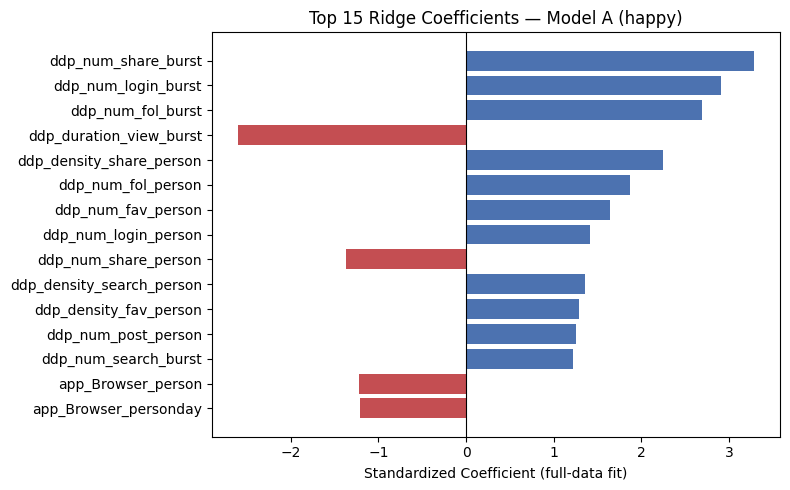

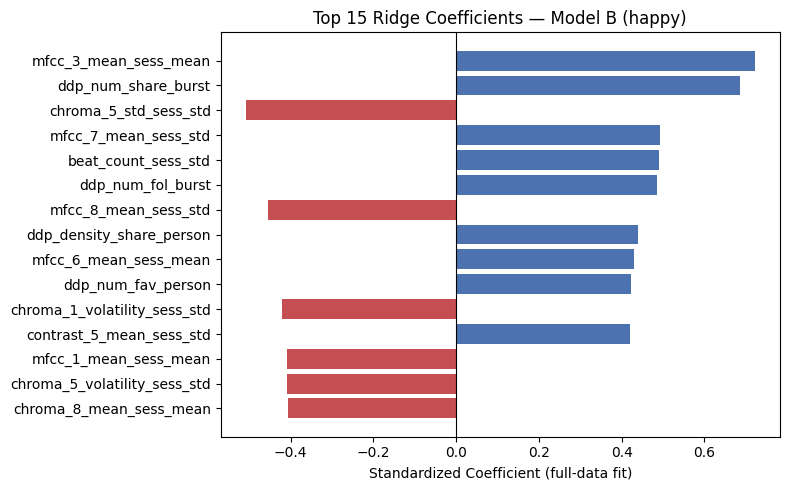

In [13]:
# Fit Models A and B on full data to inspect coefficients
# (Coefficients on standardized features — relative importance only, not effect sizes)
for model_label, cols in [("A", feat_A), ("B", feat_B)]:
    pipe = make_pipeline_AB(cols)
    pipe.fit(df_model[cols], y)
    coef = pipe.named_steps["ridge"].coef_
    coef_df = pd.DataFrame({"feature": cols, "coefficient": coef})
    coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

    top_n = 15
    top = coef_df.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top["coefficient"]]
    ax.barh(top["feature"], top["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top {top_n} Ridge Coefficients — Model {model_label} ({target})")
    ax.set_xlabel("Standardized Coefficient (full-data fit)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"coefficients_model_{model_label}.png", dpi=150)
    plt.show()

## 12. How to Use This Notebook with Another Outcome

To switch the target variable, go to **Section 4** and change:

```python
target = "happy"
```

to any of:

```python
target = "smu_intention_pc"      # Social media use intention
target = "smu_experience_happy"  # Happiness during SMU
target = "life_satisfied"        # Life satisfaction
```

Then **Kernel → Restart & Run All**.

Everything else (feature grouping, pipelines, plots) adapts automatically.
